# OpenCV-based Methods

In [2]:
import cv2

import skimage

from pathlib import Path
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from utils import remove_junction, segment_hair_fragments

In [ ]:
resolution = 132
min_size = int(0.5 * resolution)

# read a grayscale image
input_path = Path("../data/curv/004_demo_curv.tiff")
img = Image.open(input_path)
# convert to numpy array
gray_img = np.array(img.convert("L"))
# resize the image
height, width = 1446, 1794
gray_img = cv2.resize(gray_img, (width, height))

plt.imshow(gray_img, cmap="gray")

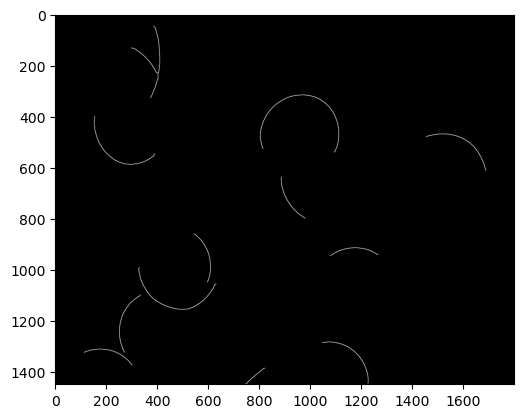

In [ ]:
skeleton = segment_hair_fragments(gray_img, min_size=min_size)
dilated = skimage.morphology.dilation(skeleton, np.ones((2, 2)))
plt.imshow(dilated, cmap="gray")

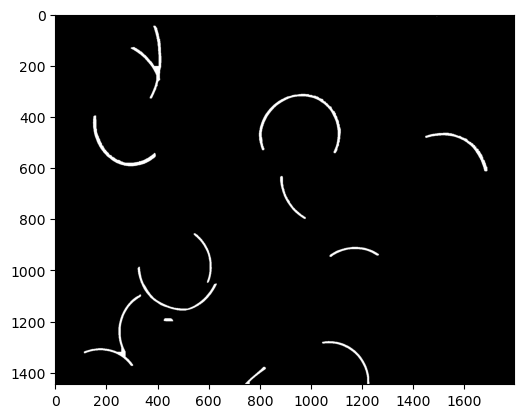

In [ ]:
# edge-based detection

# pre-filter dark regions
# create a mask for dark pixels
# threshold values can be tuned depending on your image
_, dark_mask = cv2.threshold(gray_img, 200, 255, cv2.THRESH_BINARY_INV)

# apply mask to focus on dark areas only
masked_gray = np.where(dark_mask, gray_img, 255)

# apply Gaussian blur to reduce noise and improve edge detection
blurred = cv2.GaussianBlur(masked_gray, (5, 5), 0)

# apply Canny edge detection
edges = cv2.Canny(blurred, 50, 200)

# Dilate to connect fragmented edges
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=4)

# skeletonize the image
skeleton = skimage.morphology.skeletonize(closed)
skeleton = skimage.morphology.remove_small_objects(skeleton, min_size=min_size, connectivity=2)

plt.imshow(closed, cmap="gray")

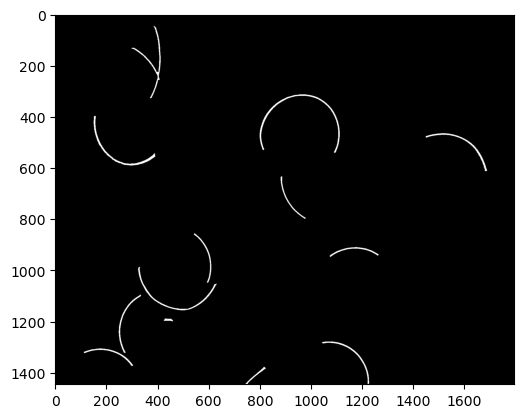

In [ ]:
# adaptive thresholding
# apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray_img, (5, 5), 0)
# apply adaptive thresholding
adaptive_thresh = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 9
)

# Dilate to connect fragmented edges
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
closed = cv2.morphologyEx(adaptive_thresh, cv2.MORPH_CLOSE, kernel, iterations=3)

# skeletonize the image
skeleton = skimage.morphology.skeletonize(closed)
skeleton = skimage.morphology.remove_small_objects(skeleton, min_size=min_size, connectivity=2)

plt.imshow(closed, cmap="gray")

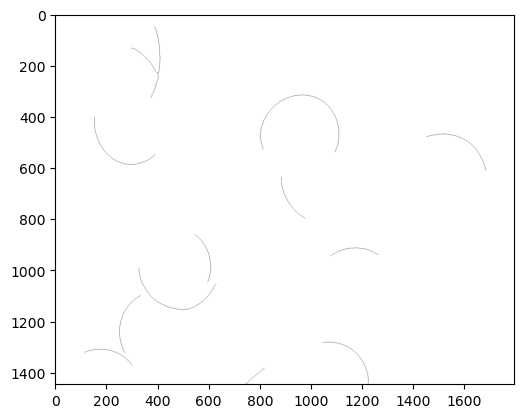

In [ ]:
plt.imshow(skimage.util.invert(skeleton), cmap="gray")

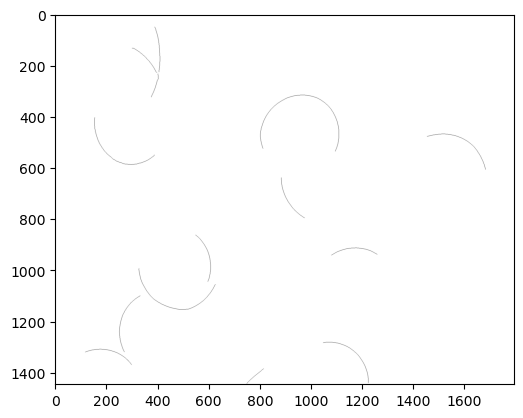

In [ ]:
removed_img = remove_junction(skeleton)
plt.imshow(skimage.util.invert(removed_img), cmap="gray")

In [ ]:
labels, num_labels = skimage.measure.label(skeleton, connectivity=2, return_num=True)
num_labels

12

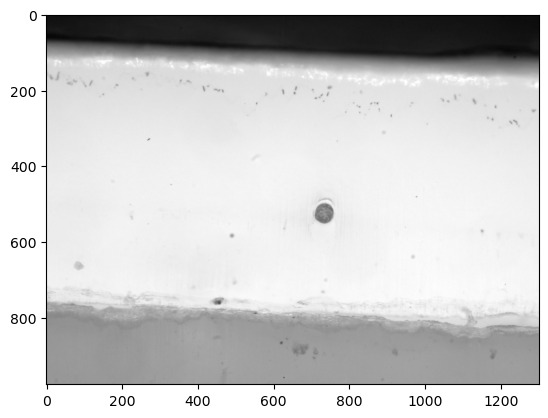

In [112]:
resolution = 132
min_size = 500
max_size = 20000
pad = 100

# read a grayscale image
input_path = Path("../data/real_section/001_A_4.tiff")
img = Image.open(input_path)
# convert to numpy array
gray_img = np.array(img.convert("L"))
# resize the image
height, width = 976, 1300
gray_img = cv2.resize(gray_img, (width, height))

plt.imshow(gray_img, cmap="gray")

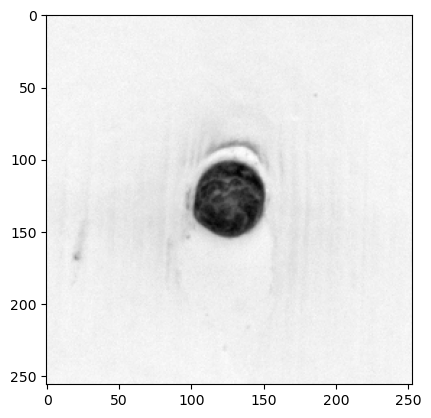

In [113]:
im_center = np.array(gray_img.shape) // 2

_, thresh = cv2.threshold(gray_img, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_DILATE, np.ones((3, 3)), iterations=3)
bin_img = skimage.segmentation.clear_border(thresh)
# label the image
label_im, num_elem = skimage.measure.label(
    bin_img, connectivity=2, return_num=True
)
# region properties
props = skimage.measure.regionprops(label_image=label_im, intensity_image=gray_img)
props = [region for region in props if region.area > min_size and region.area < max_size]
# calculate the distances between the centroids of the regions and the image center
distances = [np.linalg.norm(region.centroid - im_center) for region in props]
section = props[np.argmin(distances)]

# crop the image to the selected region
minr, minc, maxr, maxc = section.bbox
crop_img = gray_img[minr-pad:maxr+pad, minc-pad:maxc+pad]
plt.imshow(crop_img, cmap="gray")


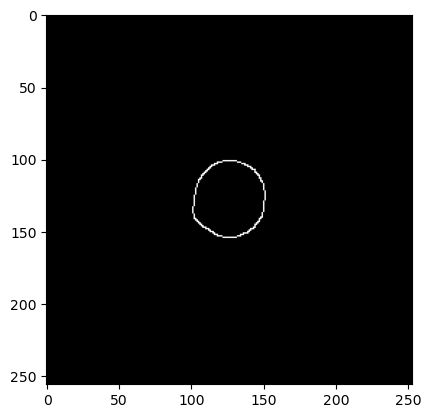

In [114]:
# edge-based detection

# pre-filter dark regions
# create a mask for dark pixels
# threshold values can be tuned depending on your image
_, dark_mask = cv2.threshold(crop_img, 200, 255, cv2.THRESH_BINARY_INV)

# apply mask to focus on dark areas only
masked_gray = np.where(dark_mask, crop_img, 255)

# apply Gaussian blur to reduce noise and improve edge detection
blurred = cv2.GaussianBlur(masked_gray, (5, 5), 0)

# apply Canny edge detection
edges = cv2.Canny(blurred, 50, 200)

plt.imshow(edges, cmap="gray")

In [115]:
crop_im_center = np.array(crop_img.shape) // 2
_, thresh = cv2.threshold(crop_img, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

seg_im = skimage.segmentation.morphological_chan_vese(
    crop_img, 40, init_level_set=thresh, smoothing=4
)

crop_label_im, num_elem = skimage.measure.label(
    seg_im, connectivity=2, return_num=True
)

crop_props = skimage.measure.regionprops(
    label_image=crop_label_im, intensity_image=crop_img
)
crop_props = [region for region in crop_props if region.area > min_size and region.area < max_size]
# calculate the distances between the centroids of the regions and the image center
distances = [np.linalg.norm(region.centroid - crop_im_center) for region in crop_props]
section = crop_props[np.argmin(distances)]

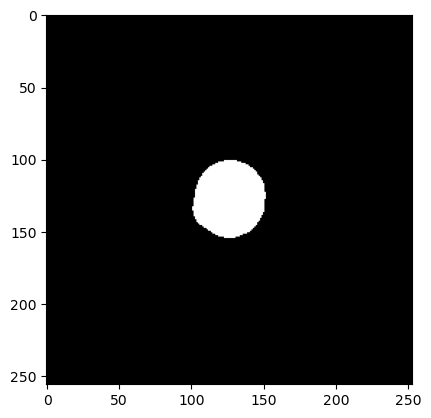

In [116]:
plt.imshow(seg_im, cmap="gray")